# TSlearn inside

Whenever pairwise distances need to be computed:

     - DBSCAN
     - KMeans (both TimeSeriesKMeans and KernelKMeans)
     - Neighbors
     - Silhouette score
     - cdist functions

an n_jobs parameter is available

***
⚠️ **Increasing n_jobs might deteriorate perfs**
***

## How it works under the hood

In [5]:
# Example
from timeit import timeit

from tslearn.generators import random_walks
from tslearn.metrics import cdist_dtw

X = random_walks(n_ts=100, sz=50, d=1)

# cdist computes n_ts*(n_ts - 1)/2 DTW
print("Serial compute", timeit('cdist_dtw(X, n_jobs=None)', number=10, globals=globals()),
      "Parallel compute" , timeit('cdist_dtw(X, n_jobs=-1)', number=10, globals=globals()))

Serial compute 0.6626093700178899 Parallel compute 1.5385098080150783


In [6]:
from tslearn.metrics._dtw import _njit_dtw

print("DTW compute", timeit('_njit_dtw(X[0], X[1])', number=10, globals=globals()))

DTW compute 0.0005712440179195255


***
Here, the cost of parallelism is too important compared to the benefits. Each DTW is fast to compute. The benefit of parallelization appears when each DTW computation takes some time.
***

In [7]:
# Features do not impact much ...
X = random_walks(n_ts=100, sz=50, d=10)

print("Serial compute", timeit('cdist_dtw(X, n_jobs=None)', number=10, globals=globals()),
      "Parallel compute" , timeit('cdist_dtw(X, n_jobs=-1)', number=10, globals=globals()))


Serial compute 0.8143230220011901 Parallel compute 1.671728068991797


In [8]:
from tslearn.metrics._dtw import _njit_dtw

print("DTW compute", timeit('_njit_dtw(X[0], X[1])', number=10, globals=globals()))

DTW compute 0.0004396490112412721


In [9]:
# But
from tslearn.metrics._dtw import _njit_dtw

X = random_walks(n_ts=100, sz=50, d=100)
print("DTW compute", timeit('_njit_dtw(X[0], X[1])', number=10, globals=globals()))

DTW compute 0.0008343920053448528


In [24]:
print("Serial compute", timeit('cdist_dtw(X, n_jobs=None)', number=10, globals=globals()),
      "Parrallel compute" , timeit('cdist_dtw(X, n_jobs=2)', number=10, globals=globals()))

Serial compute 18.243169708002824 Parrallel compute 9.570053500006907


***
The DTW is quadratic relative to the size of TS
***

In [11]:
# X2 10 times longuer, computation *100 
from tslearn.metrics._dtw import _njit_dtw

X1 = random_walks(n_ts=2, sz=100, d=2)
X2 = random_walks(n_ts=2, sz=1000, d=2)
print("Small computation", timeit('_njit_dtw(X1[0], X1[1])', number=10, globals=globals()),
      "Large compute" , timeit('_njit_dtw(X2[0], X2[1])', number=10, globals=globals()))

Small computation 0.000631810020422563 Large compute 0.06659112698980607


That's where n_job comes in handy

In [12]:
X = random_walks(n_ts=10, sz=1000, d=100)
print("Serial compute", timeit('cdist_dtw(X, n_jobs=None)', number=10, globals=globals())
      "Parrallel compute" , timeit('cdist_dtw(X, n_jobs=-1)', number=10, globals=globals()))

Serial compute 19.775424051011214 Parrallel compute 5.863293586997315


In [13]:
# Using internal _cdist_dtw here to trim artefacts due to input checks/formatting
import numpy as np
from tslearn.metrics._dtw import _cdist_dtw

serial = []
parallel = []
sizes = [int(sz) for sz in np.logspace(1, 3, 50)]
for sz in sizes:
    X = random_walks(n_ts=10, sz=sz, d=100)
    serial.append(timeit('_cdist_dtw(X, n_jobs=None)', number=10, globals=globals()))
    parallel.append(timeit('_cdist_dtw(X, n_jobs=10)', number=10, globals=globals()))

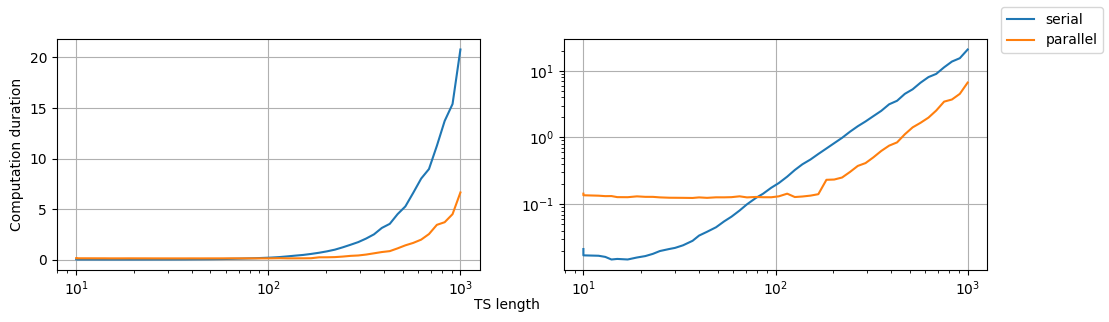

In [22]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 3), sharex=True)

axs[0].plot(sizes, serial, label="serial")
axs[0].plot(sizes, parallel, label="parallel")
axs[0].grid()
axs[0].set_ylabel("Computation duration")
axs[1].loglog(sizes, serial, label="__nolegend__")
axs[1].loglog(sizes, parallel, label="__nolegend__")
axs[1].grid()
fig.legend()
fig.text(0.5, -0.02, "TS length", ha='center')
plt.show()
